In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("train.txt", header=None, sep=';', names=['text', 'emotion'])

In [5]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [6]:
df['emotion'].unique()

array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
      dtype=object)

In [7]:
emotion_unique = df['emotion'].unique()

In [8]:
emotion_no = {}
i = 1

for emo in emotion_unique:
    emotion_no[emo] = i
    i += 1

df['emotion'] = df['emotion'].map(emotion_no)

In [9]:
emotion_no

{'sadness': 1, 'anger': 2, 'love': 3, 'surprise': 4, 'fear': 5, 'joy': 6}

In [10]:
df.head()

,text,emotion
0,i didnt feel humiliated,1
1,i can go from feeling so hopeless to so damned...,1
2,im grabbing a minute to post i feel greedy wrong,2
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,2


In [11]:
df['text'] = df['text'].apply(lambda x: x.lower())

In [12]:
df

,text,emotion
0,i didnt feel humiliated,1
1,i can go from feeling so hopeless to so damned...,1
2,im grabbing a minute to post i feel greedy wrong,2
3,i am ever feeling nostalgic about the fireplac...,3
4,i am feeling grouchy,2
...,...,...
15995,i just had a very brief time in the beanbag an...,1
15996,i am now turning and i feel pathetic that i am...,1
15997,i feel strong and good overall,6
15998,i feel like this was such a rude comment and i...,2


In [13]:
# 2 Remove Punctuation

import string

def remove_punc(txt):
    return txt.translate(str.maketrans('','',string.punctuation))


df['text'] = df['text'].apply(remove_punc)

In [14]:
df.sample(5)

,text,emotion
9949,i feel like having read ulysses is a club of r...,6
3713,i get to know about it the more guilty i feel ...,3
625,i get an anxious feeling i feel xox soon itll ...,6
7531,i am the only bright spot he has now i feel as...,1
5007,i feel troubled and also terrified your minute...,1


In [15]:
# 3 Remove Numbers

def remove_num(txt):
    new = ""
    for i in txt:
        if not i.isdigit():
            new += i
    return new

df['text'] = df['text'].apply(remove_num)

In [16]:
# 4 Remove Emojis

# example for understanding
sentence = "Hello i am your👌 GrandFather🔥"

empty = ""
for i in sentence:
    if not i.isascii():
        empty += i

print(empty)

👌🔥


In [17]:
def remove_emoji(txt):
    new = ""
    for i in txt:
        if i.isascii():
            new += i
    return new

df['text'] = df['text'].apply(remove_emoji)

In [18]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [19]:
# 5 Removing Stop words we used NLTK

import nltk
nltk.download('punkt_tab')

sentence = """At eight o'clock on Thursday morning Arthur didn't feel very good."""

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sathv\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [20]:
sentence

"At eight o'clock on Thursday morning Arthur didn't feel very good."

In [21]:
tokens = nltk.word_tokenize(sentence)
tokens

['At',
 'eight',
 "o'clock",
 'on',
 'Thursday',
 'morning',
 'Arthur',
 'did',
 "n't",
 'feel',
 'very',
 'good',
 '.']

In [22]:
from nltk.corpus import treebank
nltk.download('treebank')

[nltk_data] Downloading package treebank to
[nltk_data]     C:\Users\sathv\AppData\Roaming\nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [23]:
t = treebank.parsed_sents('wsj_0001.mrg')[0]
t.draw()

In [24]:
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sathv\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sathv\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
stop_words = set(stopwords.words('english'))

In [26]:
len(stop_words)

198

In [27]:
df.loc[1]['text']

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [28]:
# Checking with only 1 data

sen = df.loc[1]['text']

tokens = nltk.word_tokenize(sen)
empty = []

for token in tokens:
    if token not in stop_words:
        empty.append(token)
        
print(' '.join(empty))

go feeling hopeless damned hopeful around someone cares awake


In [29]:
# Now lets go for all data

def remove_stop_words(txt):
    words = nltk.word_tokenize(txt)
    data = []

    for word in words:
        if not word in stop_words:
            data.append(word)
    return ' '.join(data)

df['text'] = df['text'].apply(remove_stop_words)

In [30]:
df

,text,emotion
0,didnt feel humiliated,1
1,go feeling hopeless damned hopeful around some...,1
2,im grabbing minute post feel greedy wrong,2
3,ever feeling nostalgic fireplace know still pr...,3
4,feeling grouchy,2
...,...,...
15995,brief time beanbag said anna feel like beaten,1
15996,turning feel pathetic still waiting tables sub...,1
15997,feel strong good overall,6
15998,feel like rude comment im glad,2


In [34]:
import seaborn as sns

In [40]:
emotion_count = df.value_counts('emotion').sort_index()
emotion_count

emotion
1    4666
2    2159
3    1304
4     572
5    1937
6    5362
Name: count, dtype: int64

In [42]:
import matplotlib.pyplot as plt

<Axes: ylabel='count'>

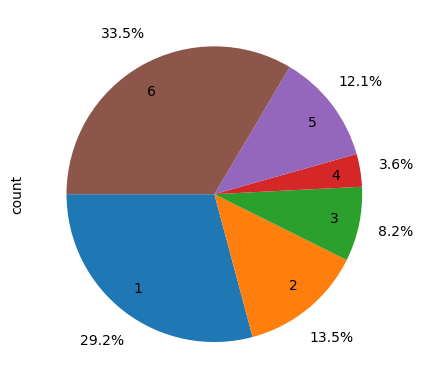

In [65]:
# explode=(0, 0, )
emotion_count.plot(kind='pie', autopct='%1.1f%%', startangle=180, pctdistance=1.25, labeldistance=0.80)

C:\Users\sathv\AppData\Local\Temp\ipykernel_17716\2180339045.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['emotion'], palette='viridis')


<Axes: xlabel='emotion', ylabel='count'>

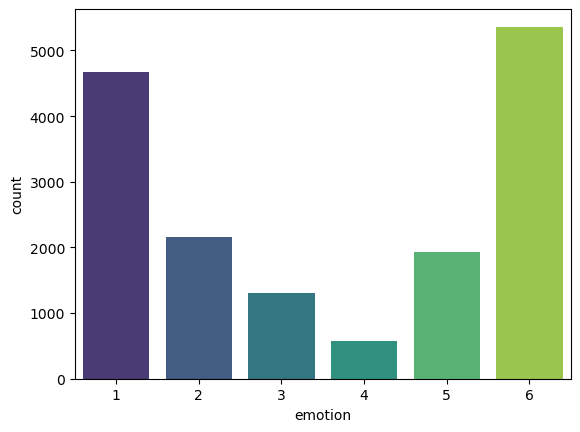

In [33]:
sns.countplot(x=df['emotion'], palette='viridis')

## Model creating 

In [65]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [28]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.20, random_state=42)

In [29]:
bow_vectorizer = CountVectorizer()

In [30]:
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

In [31]:
model_nb = MultinomialNB()

In [32]:
model_nb.fit(X_train_bow, y_train)

MultinomialNB()

In [33]:
y_pred_bow = model_nb.predict(X_test_bow)
print(accuracy_score(y_test, y_pred_bow))

0.7678125


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [44]:
model_nb2 = MultinomialNB()

model_nb2.fit(X_train_tfidf, y_train)

MultinomialNB()

In [45]:
pred_tfidf = model_nb2.predict(X_test_tfidf)

In [46]:
print(accuracy_score(y_test, pred_tfidf))

0.6609375


In [47]:
# Use Logistic for predicting model

from sklearn.linear_model import LogisticRegression

In [48]:
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [49]:
pred_lr_tfidf = model_lr.predict(X_test_tfidf)
print(accuracy_score(y_test, pred_lr_tfidf))

0.8615625


In [50]:
# Use SVM 

from sklearn.svm import SVC

model_svm = SVC(kernel='rbf', gamma='scale')
model_svm.fit(X_train_tfidf, y_train)

SVC()

In [51]:
pred_svm_tfidf = model_svm.predict(X_test_tfidf)
print(accuracy_score(y_test, pred_svm_tfidf))

0.8515625


In [53]:
# Use LinearSVC and TF-IDF

from sklearn.svm import LinearSVC

model_linearsvc = LinearSVC()

model_linearsvc.fit(X_train_tfidf, y_train)
pred = model_linearsvc.predict(X_test_tfidf)

In [54]:
print(accuracy_score(y_test, pred))

0.891875


In [61]:
# Hyperparameter tuning of TF-IDF vectorizer

vectorizer_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

X_train_param = vectorizer_tfidf.fit_transform(X_train)
X_test_param = vectorizer_tfidf.transform(X_test)

In [62]:
# Logistic Reg

model_lr2 = LogisticRegression(max_iter=1000, random_state=42)
model_lr2.fit(X_train_param, y_train)

pred_lr2 = model_lr2.predict(X_test_param)
print(accuracy_score(y_test, pred_lr2))

0.8659375


In [63]:
model_linearsvc2 = LinearSVC(max_iter=1000, class_weight='balanced')
model_linearsvc2.fit(X_train_param, y_train)

LinearSVC(class_weight='balanced')

In [64]:
pred_svc2 = model_linearsvc2.predict(X_test_param)
print(accuracy_score(y_test, pred_svc2))

0.906875


In [66]:
print(classification_report(y_test, pred_svc2))

              precision    recall  f1-score   support

           1       0.95      0.93      0.94       946
           2       0.89      0.89      0.89       427
           3       0.81      0.86      0.84       296
           4       0.80      0.80      0.80       113
           5       0.86      0.86      0.86       397
           6       0.94      0.93      0.93      1021

    accuracy                           0.91      3200
   macro avg       0.87      0.88      0.88      3200
weighted avg       0.91      0.91      0.91      3200



In [70]:
from sklearn.model_selection import GridSearchCV

params = {
    "C":[0.1, 1, 2, 10],
    "solver":['liblinear','lbfgs','sag','saga']
}

grid_search_lr = GridSearchCV(
    model_lr2, 
    params, 
    cv=5,
    n_jobs=-1,
)

grid_search_lr.fit(X_train_param, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 2, 10],
                         'solver': ['liblinear', 'lbfgs', 'sag', 'saga']})

In [71]:
pred_grid_lr = grid_search_lr.predict(X_test_param)
print(accuracy_score(y_test, pred_grid_lr))

0.9009375


In [72]:
print(grid_search_lr.best_score_)
print(grid_search_lr.best_params_)

0.8924999999999998
{'C': 10, 'solver': 'liblinear'}


## Creating Pipline for .pkl file 

In [73]:
from sklearn.pipeline import Pipeline

pipline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
    )),
    ('classifier', LinearSVC(
        max_iter=1000, 
        class_weight='balanced'
    ))
])

In [74]:
pipline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2))),
                ('classifier', LinearSVC(class_weight='balanced'))])

In [75]:
pred_pipline = pipline.predict(X_test)
print(accuracy_score(y_test, pred_pipline))

0.906875


In [76]:
print(pipline.get_params)

<bound method Pipeline.get_params of Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2))),
                ('classifier', LinearSVC(class_weight='balanced'))])>


In [77]:
# Making .pkl file

import joblib

joblib.dump(pipline, 'emotion_detection_pipline.pkl')

['emotion_detection_pipline.pkl']

In [85]:
joblib.dump(emotion_no, 'emotions.pkl')

['emotions.pkl']